In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
n = 240

X = pd.DataFrame({
    "PIVC": np.random.normal(0.60, 0.12, n),
    "TPJ": np.random.normal(0.56, 0.11, n),
    "Hippocampus": np.random.normal(0.64, 0.10, n),
    "Parietal": np.random.normal(0.58, 0.09, n),
    "Insula": np.random.normal(0.51, 0.10, n),
    "Cerebellum": np.random.normal(0.47, 0.11, n)
})

y = (
    32
    + X["Hippocampus"] * 23
    + X["PIVC"] * 16
    + X["Parietal"] * 12
    + np.random.normal(0, 5, n)
)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

errors = pd.DataFrame({
    "actual": y_test,
    "predicted": pred
})

errors["absolute_error"] = np.abs(
    errors["actual"] - errors["predicted"]
)

mae = mean_absolute_error(y_test, pred)
mae

4.50614958561747

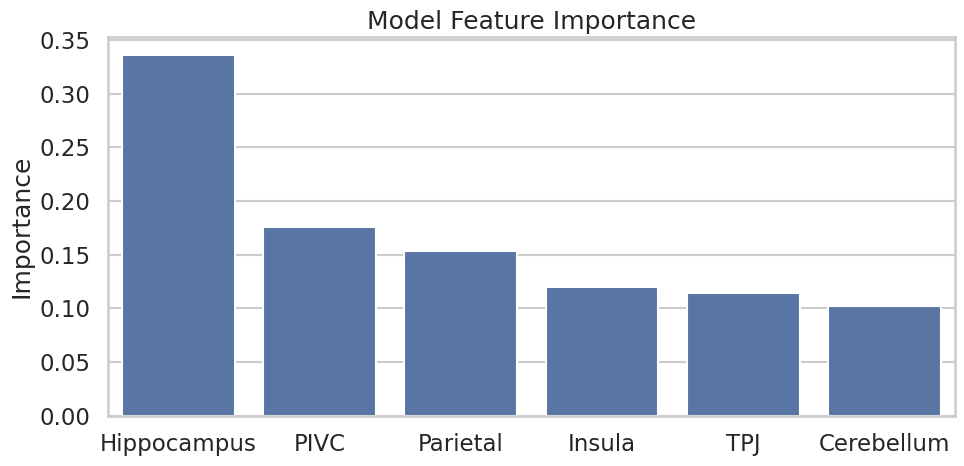

In [5]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    data=importance,
    x="feature",
    y="importance"
)

plt.xlabel("")
plt.ylabel("Importance")
plt.title("Model Feature Importance")
plt.tight_layout()
plt.savefig("figures/04_feature_importance.png", dpi=300)
plt.show()

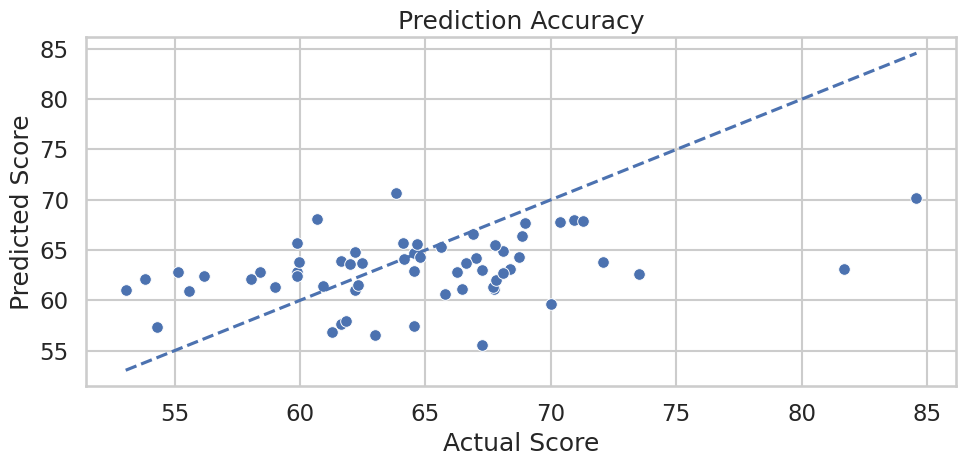

In [6]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=errors,
    x="actual",
    y="predicted",
    s=70
)

lims = [
    min(errors["actual"].min(), errors["predicted"].min()),
    max(errors["actual"].max(), errors["predicted"].max())
]

plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Prediction Accuracy")
plt.tight_layout()
plt.savefig("figures/04_prediction_accuracy.png", dpi=300)
plt.show()

In [7]:
importance.to_csv("outputs/04_feature_importance.csv", index=False)
errors.to_csv("outputs/04_prediction_errors.csv", index=False)

importance

,feature,importance
2,Hippocampus,0.335690
0,PIVC,0.175825
3,Parietal,0.153240
4,Insula,0.119526
1,TPJ,0.113940
5,Cerebellum,0.101779
